In [1]:
import preprocessing
%load_ext autoreload

In [5]:
autoreload

##データ加工

In [100]:
results_preprocessed=preprocessing.process_results()

In [101]:
results_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140686 entries, 41778 to 39941
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   race_id      140686 non-null  int64  
 1   horse_id     140686 non-null  int64  
 2   jockey_id    140686 non-null  int64  
 3   trainer_id   140686 non-null  int64  
 4   rank         140686 non-null  int64  
 5   wakuban      140686 non-null  int64  
 6   umaban       140686 non-null  int64  
 7   sex          140686 non-null  int64  
 8   age          140686 non-null  int64  
 9   weight       140686 non-null  int64  
 10  weight_diff  140686 non-null  int64  
 11  tansyo_odds  140686 non-null  float64
 12  popularity   140686 non-null  int64  
 13  impost       140686 non-null  float64
 14  agari        140685 non-null  float64
dtypes: float64(3), int64(12)
memory usage: 17.2 MB


In [102]:
#重複チェック
results_preprocessed.duplicated(subset=["race_id","horse_id"]).sum()

0

In [103]:
#欠損チェック
results_preprocessed.isnull().sum()

race_id        0
horse_id       0
jockey_id      0
trainer_id     0
rank           0
wakuban        0
umaban         0
sex            0
age            0
weight         0
weight_diff    0
tansyo_odds    0
popularity     0
impost         0
agari          1
dtype: int64

In [104]:
horse_results_preprocessed=preprocessing.process_horse_results()

/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/preprocessing.py:171: DtypeWarning: Columns (3,12,16,17,20,27,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_dir/save_filename, sep="\t")


In [105]:
horse_results_preprocessed

,horse_id,date,rank,prize,rank_diff,weather,race_type,course_len,ground_state,agari,race_class,n_horses
0,2011106610,2014-01-19,6,0.0,0.7,0.0,1,1600,0.0,37.4,0.0,16.0
1,2011106610,2014-03-01,1,500.0,0.0,1.0,1,1800,0.0,35.8,1.0,16.0
2,2011106610,2014-03-23,12,0.0,2.6,0.0,1,1800,0.0,38.6,NaN,15.0
3,2011106610,2014-04-19,8,0.0,0.6,0.0,1,1600,0.0,35.4,2.0,13.0
4,2011106610,2014-05-25,10,0.0,0.6,0.0,1,1600,0.0,35.1,2.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...
341149,2022190001,2024-08-04,1,0.0,NaN,NaN,1,1700,2.0,NaN,1.0,10.0
341150,2022190001,2024-09-08,1,0.0,NaN,NaN,1,1600,0.0,NaN,5.0,12.0
341151,2022190001,2024-10-04,1,0.0,NaN,NaN,1,1700,0.0,NaN,NaN,11.0
341152,2022190001,2024-11-02,2,0.0,NaN,NaN,1,1600,0.0,NaN,NaN,14.0


In [106]:
horse_results_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 228254 entries, 0 to 341153
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   horse_id      228254 non-null  int64         
 1   date          228254 non-null  datetime64[ns]
 2   rank          228254 non-null  int64         
 3   prize         228254 non-null  float64       
 4   rank_diff     227910 non-null  float64       
 5   weather       227953 non-null  float64       
 6   race_type     228254 non-null  int64         
 7   course_len    228254 non-null  int64         
 8   ground_state  228250 non-null  float64       
 9   agari         227902 non-null  float64       
 10  race_class    198932 non-null  float64       
 11  n_horses      228254 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(4)
memory usage: 22.6 MB


In [107]:
race_info_preprocessed=preprocessing.process_race_info()

In [108]:
race_info_preprocessed

,race_id,date,race_type,around_dir,around_inout,course_abc,course_len,weather,ground_state,race_class,place
0,202406010111,2024-01-06,1,0,-1,-1,2000,0,0,5,2
1,202503020112,2025-06-28,0,0,-1,-1,1700,0,0,2,9
2,202509050506,2025-12-20,0,0,-1,-1,1800,0,0,0,1
3,202309020109,2023-03-25,1,0,1,-1,1800,1,0,2,1
4,202303020408,2023-07-09,1,0,-1,-1,1800,1,0,2,9
...,...,...,...,...,...,...,...,...,...,...,...
10360,202501010302,2025-08-02,0,0,-1,-1,1000,0,0,1,5
10361,202403020406,2024-07-07,1,0,-1,-1,1200,0,0,0,9
10362,202505040205,2025-10-05,1,1,-1,-1,2000,0,0,0,0
10363,202408060403,2024-11-10,1,0,-1,-1,1600,0,0,1,3


##  特徴量作成

In [109]:
from feature_engineering import FeatureCreator

In [110]:
fc=FeatureCreator()

In [111]:
fc.results

,race_id,horse_id,jockey_id,trainer_id,rank,wakuban,umaban,sex,age,weight,weight_diff,tansyo_odds,popularity,impost,agari
0,202301010101,2021100648,1095,1128,5,1,1,1,2,434,0,23.9,5,55.0,34.5
1,202301010101,2021100159,1157,1186,6,2,2,0,2,454,6,61.8,7,55.0,35.1
2,202301010101,2021100265,1197,1192,7,3,3,1,2,404,2,18.8,4,53.0,35.3
3,202301010101,2021105553,5339,1160,4,4,4,1,2,450,2,16.6,3,55.0,34.9
4,202301010101,2021101429,1170,1026,1,5,5,0,2,452,4,1.2,1,55.0,34.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140681,202510020812,2022105755,1187,1135,5,7,14,1,3,452,4,7.2,3,53.0,34.5
140682,202510020812,2017101767,1125,1120,12,7,15,0,8,480,8,111.0,16,58.0,34.9
140683,202510020812,2020106727,1213,1205,8,8,16,0,5,544,0,18.1,5,58.0,35.3
140684,202510020812,2021103312,1154,1157,3,8,17,0,4,496,8,29.0,8,58.0,34.7


In [112]:
fc.horse_results

,horse_id,date,rank,prize,rank_diff,weather,race_type,course_len,ground_state,agari,race_class,n_horses
0,2011106610,2014-01-19,6,0.0,0.7,0.0,1,1600,0.0,37.4,0.0,16.0
1,2011106610,2014-03-01,1,500.0,0.0,1.0,1,1800,0.0,35.8,1.0,16.0
2,2011106610,2014-03-23,12,0.0,2.6,0.0,1,1800,0.0,38.6,NaN,15.0
3,2011106610,2014-04-19,8,0.0,0.6,0.0,1,1600,0.0,35.4,2.0,13.0
4,2011106610,2014-05-25,10,0.0,0.6,0.0,1,1600,0.0,35.1,2.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...
228249,2022190001,2024-08-04,1,0.0,NaN,NaN,1,1700,2.0,NaN,1.0,10.0
228250,2022190001,2024-09-08,1,0.0,NaN,NaN,1,1600,0.0,NaN,5.0,12.0
228251,2022190001,2024-10-04,1,0.0,NaN,NaN,1,1700,0.0,NaN,NaN,11.0
228252,2022190001,2024-11-02,2,0.0,NaN,NaN,1,1600,0.0,NaN,NaN,14.0


In [113]:
features=fc.create_features()

In [115]:
features

,race_id,horse_id,date,jockey_id,trainer_id,rank,wakuban,umaban,sex,age,...,race_class,place,rank_3races,prize_3races,rank_5races,prize_5races,rank_10races,prize_10races,rank_1000races,prize_1000races
0,202301010101,2021100648,2023-07-22,1095,1128,5,1,1,1,2,...,1,5,4.500000,77.500000,4.500000,77.500000,4.500000,77.500000,4.500000,77.500000
1,202301010101,2021100159,2023-07-22,1157,1186,6,2,2,0,2,...,1,5,8.000000,0.000000,8.000000,0.000000,8.000000,0.000000,8.000000,0.000000
2,202301010101,2021100265,2023-07-22,1197,1192,7,3,3,1,2,...,1,5,5.000000,72.000000,5.000000,72.000000,5.000000,72.000000,5.000000,72.000000
3,202301010101,2021105553,2023-07-22,5339,1160,4,4,4,1,2,...,1,5,4.000000,110.000000,4.000000,110.000000,4.000000,110.000000,4.000000,110.000000
4,202301010101,2021101429,2023-07-22,1170,1026,1,5,5,0,2,...,1,5,2.000000,290.000000,2.000000,290.000000,2.000000,290.000000,2.000000,290.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140681,202510020812,2022105755,2025-07-20,1187,1135,5,7,14,1,3,...,3,8,4.000000,754.433333,4.000000,596.660000,4.000000,596.660000,4.000000,596.660000
140682,202510020812,2017101767,2025-07-20,1125,1120,12,7,15,0,8,...,3,8,10.333333,0.000000,9.400000,22.800000,7.000000,106.210000,5.684211,102.284211
140683,202510020812,2020106727,2025-07-20,1213,1205,8,8,16,0,5,...,3,8,6.000000,132.066667,7.200000,79.240000,5.500000,206.620000,5.636364,187.836364
140684,202510020812,2021103312,2025-07-20,1154,1157,3,8,17,0,4,...,3,8,4.333333,173.333333,3.400000,252.880000,3.125000,269.925000,3.125000,269.925000


##  学習

In [116]:
from train import Trainer, create_yaml

In [117]:
#単勝系モデル
create_yaml(delete_col=["race_id", "date", "rank", "target","popularity","tansyo_odds"],)
r_win=Trainer()
evaluation_df=r_win.run(test_start_date="2025-05-01")

YAML ファイルを作成しました: config.yaml
(109295, 34) (31391, 34)


/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/train.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[c] = s_tr.astype("category").cat.set_categories(category_map[c])
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/train.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[c] = test_df[c].astype("string").astype("category").cat.set_categories(category_map[c])
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/train.py:89: SettingWithCopyWarning: 
A value is trying to be set

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 7984, number of negative: 101311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16301
[LightGBM] [Info] Number of data points in the train set: 109295, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073050 -> initscore=-2.540755
[LightGBM] [Info] Start training from score -2.540755
Training until validation scores don't improve for 100 rounds
[100]	valid's binary_logloss: 0.234144
Early stopping, best iteration is:
[42]	valid's binary_logloss: 0.231703
--------------------result---------

In [118]:
# 3連系モデル
from train_trifecta import Trainer, create_yaml

create_yaml(delete_col=["race_id", "date", "rank", "target","popularity","tansyo_odds"],)
r_tri=Trainer()
evaluation_df_tri=r_tri.run(test_start_date="2025-05-01")

[OK] YAML created: config_tri.yaml
[OK] num_features: 28
Training until validation scores don't improve for 300 rounds
[100]	valid_0's ndcg@1: 0.467309	valid_0's ndcg@3: 0.575243	valid_0's ndcg@5: 0.654649
[200]	valid_0's ndcg@1: 0.484437	valid_0's ndcg@3: 0.593632	valid_0's ndcg@5: 0.674159
[300]	valid_0's ndcg@1: 0.49119	valid_0's ndcg@3: 0.601437	valid_0's ndcg@5: 0.681879
[400]	valid_0's ndcg@1: 0.495672	valid_0's ndcg@3: 0.605219	valid_0's ndcg@5: 0.683465
[500]	valid_0's ndcg@1: 0.498189	valid_0's ndcg@3: 0.607234	valid_0's ndcg@5: 0.68797
[600]	valid_0's ndcg@1: 0.495611	valid_0's ndcg@3: 0.609121	valid_0's ndcg@5: 0.688934
[700]	valid_0's ndcg@1: 0.497145	valid_0's ndcg@3: 0.609391	valid_0's ndcg@5: 0.689518
[800]	valid_0's ndcg@1: 0.497636	valid_0's ndcg@3: 0.610011	valid_0's ndcg@5: 0.690784
Early stopping, best iteration is:
[550]	valid_0's ndcg@1: 0.500829	valid_0's ndcg@3: 0.608618	valid_0's ndcg@5: 0.689094


In [119]:
from feature_engineering  import  PredictionFeatureCreator
pfc=PredictionFeatureCreator()

##  レース予想

In [1]:
%load_ext autoreload

In [2]:
autoreload

In [3]:
from datetime import datetime

kaisai_date = "2026-01-25"
mmdd = datetime.strptime(kaisai_date, "%Y-%m-%d").strftime("%m%d")


In [4]:
import preprocessing
from feature_engineering  import  PredictionFeatureCreator

horse_results_preprocessed=preprocessing.process_horse_results(
    save_filename="horse_results_prediction_"+str(mmdd)+".csv"
)
pfc=PredictionFeatureCreator(population_file_name= "population_"+str(mmdd)+".csv",
        horse_results_prediction_feile_name = "horse_results_prediction_"+str(mmdd)+".csv")

/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/preprocessing.py:171: DtypeWarning: Columns (3,12,17,18,21,28,30,37,39,40,41,43,65,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_dir/save_filename, sep="\t")


In [5]:
horse_results_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5385 entries, 73 to 24162
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   horse_id      5385 non-null   int64         
 1   date          5385 non-null   datetime64[ns]
 2   rank          5385 non-null   int64         
 3   prize         5385 non-null   float64       
 4   rank_diff     5380 non-null   float64       
 5   weather       5380 non-null   float64       
 6   race_type     5385 non-null   int64         
 7   course_len    5385 non-null   int64         
 8   ground_state  5384 non-null   float64       
 9   agari         5380 non-null   float64       
 10  race_class    4783 non-null   float64       
 11  n_horses      5384 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(4)
memory usage: 546.9 KB


## レース当日

In [12]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
autoreload

In [14]:
pfc=PredictionFeatureCreator(population_file_name:="population_"+str(mmdd)+".csv",
        horse_results_prediction_feile_name="horse_results_prediction_"+str(mmdd)+".csv")
pfc.agg_horse_n_races()

In [15]:
pfc.agg_horse_n_races_df

,date,race_id,horse_id,rank_3races,prize_3races,rank_5races,prize_5races,rank_10races,prize_10races,rank_1000races,prize_1000races
0,2026-01-25,202606010906,2022100182,10.000000,0.000000,6.8,140.00,7.444444,96.444444,7.444444,96.444444
1,2026-01-25,202606010910,2019107016,8.666667,0.000000,8.6,0.00,9.900000,18.400000,7.865385,125.982692
2,2026-01-25,202608010910,2020105354,8.333333,0.000000,6.2,205.72,6.100000,214.260000,5.047619,315.476190
3,2026-01-25,202608010910,2020105089,8.666667,93.333333,6.4,241.56,7.300000,278.090000,6.500000,226.045000
4,2026-01-25,202608010910,2019102106,9.666667,0.000000,9.4,0.00,8.200000,64.700000,6.270270,150.927027
5,2026-01-25,202610010209,2022106605,4.666667,233.333333,5.0,156.80,5.000000,105.777778,5.000000,105.777778
6,2026-01-25,202610010211,2020104550,7.000000,0.000000,5.4,205.36,5.800000,252.070000,5.230769,311.019231


In [10]:
features=pfc.create_features(
    race_id="202608010809",
    predict=True,
    skip_agg_horse=False
)
print(features.loc[:, ["race_name"]].head(1))

KeyboardInterrupt: 

In [425]:
features["tansyo_odds"].head()


0    39.7
1     6.2
2    76.3
3     3.9
4    16.3
Name: tansyo_odds, dtype: float64

In [592]:
# 単勝モデル
from prediction import predict_win
predict_win(features)


,race_id,umaban,tansyo_odds,popularity,agari,pred
0,202608010809,1,38.6,10,NaN,0.03662
1,202608010809,2,6.3,4,NaN,0.03662
2,202608010809,3,74.1,12,NaN,0.03662
3,202608010809,4,4.1,2,NaN,0.03662
4,202608010809,5,16.8,7,NaN,0.03662
5,202608010809,6,77.1,13,NaN,0.03662
6,202608010809,7,6.2,3,NaN,0.03662
7,202608010809,8,9.7,5,NaN,0.03662
8,202608010809,9,3.2,1,NaN,0.03662
9,202608010809,10,71.8,11,NaN,0.03662


In [413]:
# 3連系モデル
from prediction import predict_rank

pred_df = predict_rank(features)
pred_df

,race_id,umaban,tansyo_odds,popularity,agari,score,pred_rank
0,202608010809,12,24.0,9,NaN,1.209706,1
1,202608010809,13,14.8,6,NaN,1.209706,2
2,202608010809,1,39.7,10,NaN,1.204457,3
3,202608010809,4,3.9,2,NaN,1.200253,4
4,202608010809,8,9.9,5,NaN,1.197626,5
5,202608010809,9,3.5,1,NaN,1.197626,6
6,202608010809,10,68.5,11,NaN,1.197626,7
7,202608010809,11,22.3,8,NaN,1.197626,8
8,202608010809,3,76.3,12,NaN,1.187736,9
9,202608010809,5,16.3,7,NaN,1.187736,10


In [20]:
from report_html import build_html_report
import calibrate_confidence
import importlib, report_html
importlib.reload(report_html)
from datetime import datetime

#kaisai_date = "2026-01-24"

mmdd = datetime.strptime(kaisai_date, "%Y-%m-%d").strftime("%m%d")

calibrate_confidence.main()
out = build_html_report(target_date=kaisai_date, read_file_name_csv="population_"+str(mmdd)+".csv",read_horse_name_csv="horse_results_prediction_"+str(mmdd)+".csv",topk_per_race=18,skip_agg_horse=False)
print("Saved:", out.resolve())


KeyboardInterrupt: 

In [627]:
# 順位保存

#kaisai_date="2026-01-24"
from update_results_flat import update_results_flat_for_date
update_results_flat_for_date(kaisai_date)

[update_results_flat_for_date]
 population_csv: /home/jawa/horse_ai/horse_race_prediction/common/data/prediction_population/population_0124.csv
 html_race_dir : /home/jawa/horse_ai/horse_race_prediction/common/data/html/race
 results_flat  : /home/jawa/horse_ai/horse_race_prediction/v2_0_0/data/results_cache/results_flat.csv
 new rows      : 0
[WARN] failed races (first 10)
     race_id                                             reason
202606010801 ValueError('result table not found: 202606010801')
202606010802 ValueError('result table not found: 202606010802')
202606010803 ValueError('result table not found: 202606010803')
202606010804 ValueError('result table not found: 202606010804')
202606010805 ValueError('result table not found: 202606010805')
202606010806 ValueError('result table not found: 202606010806')
202606010807 ValueError('result table not found: 202606010807')
202606010808 ValueError('result table not found: 202606010808')
202606010809 ValueError('result table not found

/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/update_results_flat.py:231: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat([old, new_df], ignore_index=True)


(Empty DataFrame
 Columns: [date, race_id, umaban, rank, agari]
 Index: [],
 PosixPath('/home/jawa/horse_ai/horse_race_prediction/v2_0_0/data/results_cache/results_flat.csv'))

In [24]:
#払戻金保存
from update_payouts_flat import update_payouts_flat_for_date
update_payouts_flat_for_date(kaisai_date)

[update_payouts_flat_for_date]
 population_csv: /home/jawa/horse_ai/horse_race_prediction/common/data/prediction_population/population_0117.csv
 html_race_dir : /home/jawa/horse_ai/horse_race_prediction/common/data/html/race
 payouts_flat  : /home/jawa/horse_ai/horse_race_prediction/v2_0_0/data/results_cache/payouts_flat.csv
 new rows      : 0


(Empty DataFrame
 Columns: [date, race_id, bet_type, combo, pay100]
 Index: [],
 PosixPath('/home/jawa/horse_ai/horse_race_prediction/v2_0_0/data/results_cache/payouts_flat.csv'))

In [16]:
#結果表示(適宜更新)
import importlib
import report_html
import finalize_day

importlib.reload(report_html)
importlib.reload(finalize_day)   # ← これが必要
kaisai_date="2026-01-25"

out = finalize_day.finalize_day(kaisai_date, mode="auto", skip_agg_horse=False, topk_per_race=18)


[finalize_day] mode=realtime


/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/live_update.py:109: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat([old, df2], ignore_index=True)
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/live_update.py:109: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat([old, df2], ignore_index=True)
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/live_update.py:109: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is de

[live_update_two_stage]
 date: 2026-01-25
 stageA need_res : 19
 stageA updated  : 8 ['202606010907', '202606010908', '202608010906', '202608010907', '202608010908', '202610010207', '202610010208', '202610010209']
 stageB need_pay : 8
 stageB updated  : 8 ['202606010907', '202606010908', '202608010906', '202608010907', '202608010908', '202610010207', '202610010208', '202610010209']
 failed (first5): [('202606010909', 'results', "ValueError('result table not found: 202606010909')"), ('202606010910', 'results', "ValueError('result table not found: 202606010910')"), ('202606010911', 'results', "ValueError('result table not found: 202606010911')"), ('202606010912', 'results', "ValueError('result table not found: 202606010912')"), ('202608010909', 'results', "ValueError('result table not found: 202608010909')")]


Build HTML 2026-01-25:   0%|          | 0/36 [00:00<?, ?it/s]

[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 14 / 14
[INFO] popularity  via API: 14 / 14
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 18 / 18
[INFO] popularity  via API: 18 / 18
[INFO] tansyo_odds via API: 15 / 15
[INFO] popularity  via API: 15 / 15
[INFO] tansyo_odds via API: 10 / 10
[INFO] popularity  via API: 10 / 10
[INFO] tansyo_odds via API: 15 / 15
[INFO] popularity  via API: 15 / 15
[INFO] tansyo_odds via API: 12 / 12
[INFO] popularity  via API: 12 / 12
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 11 / 11
[INFO] popularity  via API: 11 / 11
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 

In [22]:
import importlib, update_payouts_flat
importlib.reload(update_payouts_flat)

from pathlib import Path
from update_payouts_flat import _parse_payouts_from_race_html_bytes, _read_bin_html

rid = "202606010610"  # 0117のrace_id
p = Path("/home/jawa/horse_ai/horse_race_prediction/common/data/html/race") / f"{rid}.bin"
df = _parse_payouts_from_race_html_bytes(rid, _read_bin_html(p))
print(df.head(50))
print("rows:", len(df))



         race_id    bet_type    combo  pay100
0   202606010610     fukusho       11     520
1   202606010610     fukusho       12     450
2   202606010610     fukusho        3     230
3   202606010610  sanrenpuku  3-11-12   24430
4   202606010610   sanrentan  3-11-12  119350
5   202606010610      tansho        3     670
6   202606010610      umaren     3-11    5250
7   202606010610      umatan     3-11    9830
8   202606010610        wide    11-12    2820
9   202606010610        wide     3-11    1650
10  202606010610        wide     3-12    1570
rows: 11


NameError: name 'df1' is not defined

In [ ]:
features["info1"]

## 訓練モデルの有効性

In [131]:
evaluation_df

,race_id,horse_id,target,rank,tansyo_odds,popularity,umaban,pred
93372,202501010101,NaN,0,12,36.9,6,1,0.046374
93373,202501010101,NaN,0,3,4.2,2,2,0.039826
93374,202501010101,NaN,1,1,4.8,3,3,0.078877
93375,202501010101,NaN,0,2,2.4,1,4,0.078108
93376,202501010101,NaN,0,9,5.5,4,5,0.147175
...,...,...,...,...,...,...,...,...
140681,202510020812,2022105755,0,5,7.2,3,14,0.122049
140682,202510020812,2017101767,0,12,111.0,16,15,0.025447
140683,202510020812,2020106727,0,8,18.1,5,16,0.081600
140684,202510020812,2021103312,0,3,29.0,8,17,0.191431


In [133]:
bet_df=(
    evaluation_df
    .sort_values("pred",ascending=False)
    .groupby("race_id")
    .head(1)
)
bet_df

,race_id,horse_id,target,rank,tansyo_odds,popularity,umaban,pred
111442,202505050311,2020103307,0,2,2.8,1,4,0.884777
135702,202509040706,NaN,0,3,1.8,1,1,0.706930
118176,202506040911,2019101700,0,4,2.2,1,7,0.695523
137087,202509050702,NaN,1,1,3.8,2,10,0.688662
130462,202508040404,NaN,1,1,3.8,2,5,0.685037
...,...,...,...,...,...,...,...,...
117515,202506040601,NaN,0,2,2.8,2,6,0.026757
117366,202506040501,NaN,1,1,14.4,2,15,0.025696
99068,202503020601,NaN,1,1,9.2,2,7,0.025361
101164,202504010403,2022102227,0,5,5.8,3,8,0.014317


In [134]:
#的中率
bet_df["target"].mean()

0.3003867640739149

In [135]:
#返ってくる金額/100
return_=((bet_df["target"]==1)*bet_df["tansyo_odds"]).sum()
print("回収額",return_)
#かけた金額
cost=len(bet_df)
print("掛け金",cost)
return_/cost

回収額 3298.2
掛け金 2327


1.4173614095401803

In [136]:
#一番人気と違う馬の回収率
bet_df=(
    evaluation_df
    .sort_values("pred",ascending=False)
    .groupby("race_id")
    .head(1)
    .query("popularity!=1")
)
#bet_df
bet_df_tekityu=bet_df.query("target==1")
ave_popu=bet_df_tekityu["popularity"].mean()
ave_odds=bet_df_tekityu["tansyo_odds"].mean()
print("的中した馬の平均人気",ave_popu)
print("的中した馬の平均オッズ",ave_odds)
worst_popu=bet_df["popularity"].max()
worst_odds=bet_df["tansyo_odds"].max()
print("当てた馬の最低人気",worst_popu)
print("当てた馬の最低オッズ",worst_odds)

的中した馬の平均人気 3.2621951219512195
的中した馬の平均オッズ 7.603963414634148
当てた馬の最低人気 17
当てた馬の最低オッズ 246.1


In [137]:
#的中率
bet_df["target"].mean()

0.21910487641950568

In [138]:
#回収率
#返ってくる金額/100
return_=((bet_df["target"]==1)*bet_df["tansyo_odds"]).sum()
#かけた金額
cost=len(bet_df)
cost
return_/cost

1.666065464261857

<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

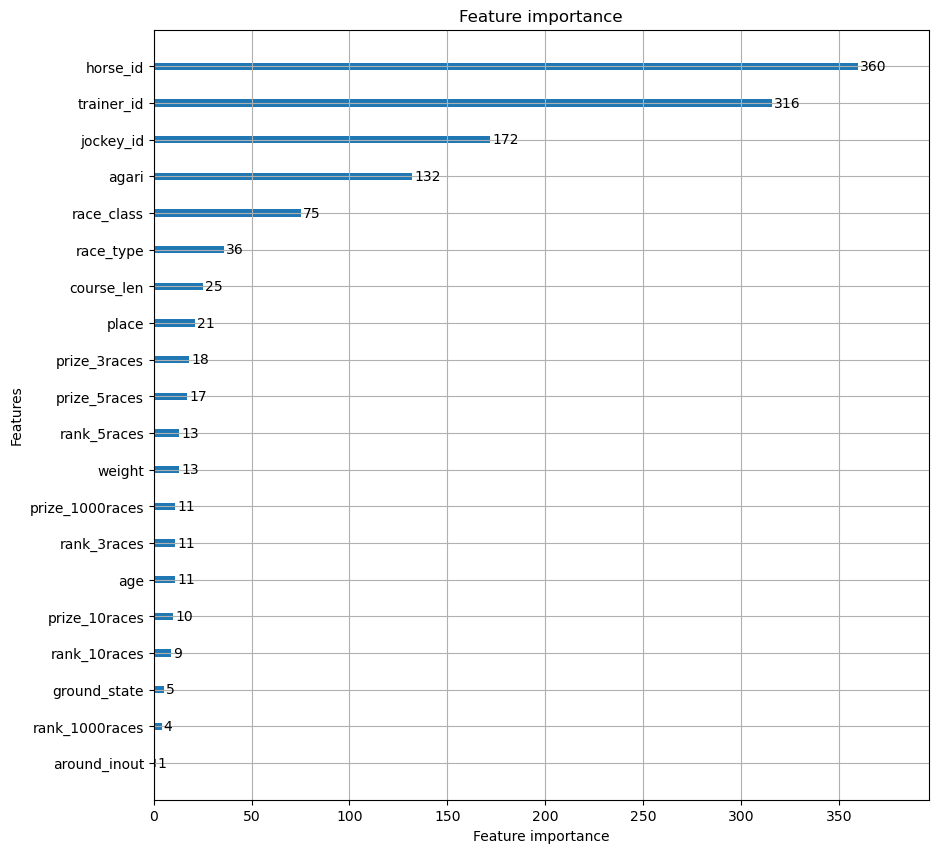

In [140]:
import lightgbm as lgb
lgb.plot_importance(r_win.model,figsize=(10,10))

In [141]:
import pandas as pd
evaluation_df.groupby(pd.cut(evaluation_df["pred"], [0,0.2,0.4,0.6,0.8,1.0])).agg(
    win_rate=("target", "mean"),
    count=("target", "count")
)


/tmp/ipykernel_64857/2046811631.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  evaluation_df.groupby(pd.cut(evaluation_df["pred"], [0,0.2,0.4,0.6,0.8,1.0])).agg(


,win_rate,count
pred,,
"(0.0, 0.2]",0.060270,29086
"(0.2, 0.4]",0.225013,1991
"(0.4, 0.6]",0.413793,290
"(0.6, 0.8]",0.391304,23
"(0.8, 1.0]",0.000000,1


In [142]:
evaluation_df["pred_bin"] = pd.qcut(evaluation_df["pred"], 10, duplicates="drop")

calib = evaluation_df.groupby("pred_bin").agg(
    mean_pred=("pred", "mean"),
    win_rate=("target", "mean"),
    count=("target", "count"),
)

calib


/tmp/ipykernel_64857/742031210.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = evaluation_df.groupby("pred_bin").agg(


,mean_pred,win_rate,count
pred_bin,,,
"(0.00224, 0.0123]",0.007854,0.001592,3140
"(0.0123, 0.0195]",0.015986,0.013699,3139
"(0.0195, 0.0267]",0.023070,0.021982,3139
"(0.0267, 0.0349]",0.030759,0.030583,3139
"(0.0349, 0.0453]",0.039949,0.038229,3139
"(0.0453, 0.0585]",0.051514,0.064670,3139
"(0.0585, 0.0778]",0.067634,0.075820,3139
"(0.0778, 0.108]",0.091356,0.113093,3139
"(0.108, 0.169]",0.134708,0.150685,3139


In [143]:
evaluation_df["rank_pred"] = (
    evaluation_df
    .groupby("race_id")["pred"]
    .rank(ascending=False)
)

evaluation_df.groupby("rank_pred")["target"].mean().head(5)


rank_pred
1.0    0.300387
2.0    0.183068
3.0    0.126343
4.0    0.097121
5.0    0.064461
Name: target, dtype: float64

In [144]:
autoreload

[OK] YAML created: config_tri.yaml
[OK] num_features: 27
Training until validation scores don't improve for 300 rounds
[100]	valid_0's ndcg@1: 0.536067	valid_0's ndcg@3: 0.637605	valid_0's ndcg@5: 0.712356
[200]	valid_0's ndcg@1: 0.551968	valid_0's ndcg@3: 0.655282	valid_0's ndcg@5: 0.730204
[300]	valid_0's ndcg@1: 0.558782	valid_0's ndcg@3: 0.663425	valid_0's ndcg@5: 0.737041
[400]	valid_0's ndcg@1: 0.561115	valid_0's ndcg@3: 0.66364	valid_0's ndcg@5: 0.73786
[500]	valid_0's ndcg@1: 0.559703	valid_0's ndcg@3: 0.662325	valid_0's ndcg@5: 0.737941
[600]	valid_0's ndcg@1: 0.55915	valid_0's ndcg@3: 0.663186	valid_0's ndcg@5: 0.738778
Early stopping, best iteration is:
[357]	valid_0's ndcg@1: 0.560562	valid_0's ndcg@3: 0.665352	valid_0's ndcg@5: 0.738381


In [110]:
from feature_engineering  import  PredictionFeatureCreator
pfc=PredictionFeatureCreator()

In [111]:
import preprocessing

horse_results_preprocessed=preprocessing.process_horse_results(
    save_filename="horse_results_prediction.csv"
)

In [112]:
horse_results_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5385 entries, 73 to 14032
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   horse_id      5385 non-null   int64         
 1   date          5385 non-null   datetime64[ns]
 2   rank          5385 non-null   int64         
 3   prize         5385 non-null   float64       
 4   rank_diff     5380 non-null   float64       
 5   weather       5380 non-null   float64       
 6   race_type     5385 non-null   int64         
 7   course_len    5385 non-null   int64         
 8   ground_state  5384 non-null   float64       
 9   agari         5380 non-null   float64       
 10  race_class    4783 non-null   float64       
 11  n_horses      5384 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(4)
memory usage: 546.9 KB


In [124]:
autoreload

In [114]:
pfc=PredictionFeatureCreator()
pfc.agg_horse_n_races()

In [115]:
pfc.agg_horse_n_races_df

,date,race_id,horse_id,rank_3races,prize_3races,rank_5races,prize_5races,rank_10races,prize_10races,rank_1000races,prize_1000races
0,2026-01-18,202606010704,2022106543,9.666667,28.000000,10.4,16.80,10.142857,12.000000,10.142857,12.000000
1,2026-01-18,202606010704,2019101612,5.000000,226.666667,8.8,136.00,7.900000,316.360000,7.263158,212.821053
2,2026-01-18,202606010704,2018105199,7.333333,113.333333,6.0,228.00,6.500000,142.000000,7.347826,127.217391
3,2026-01-18,202606010706,2022105258,1.666667,400.000000,2.4,284.80,3.300000,200.400000,3.300000,200.400000
4,2026-01-18,202606010708,2022105844,6.333333,266.666667,5.0,240.00,6.900000,120.000000,6.538462,134.615385
5,2026-01-18,202606010709,2018104757,9.333333,0.000000,8.8,0.00,9.800000,18.400000,7.361111,119.052778
6,2026-01-18,202606010709,2021100363,5.666667,154.666667,6.0,242.64,7.400000,279.610000,6.571429,409.400000
7,2026-01-18,202606010709,2019107075,9.333333,0.000000,10.0,0.00,8.900000,28.000000,6.859375,113.178125
8,2026-01-18,202606010709,2020103521,3.666667,357.100000,5.4,214.26,4.600000,313.150000,3.708333,470.895833
9,2026-01-18,202606010710,2022110140,10.666667,296.600000,7.4,596.72,5.000000,611.211111,5.000000,611.211111


In [120]:
features=pfc.create_features(
    race_id="202608010711",
    predict=True,
    skip_agg_horse=True
)

[INFO] tansyo_odds via API: 13 / 13
[INFO] popularity  via API: 13 / 13


In [121]:
features["tansyo_odds"].head()

0     83.0
1     21.1
2    154.7
3     15.5
4      7.2
Name: tansyo_odds, dtype: float64

In [122]:
from prediction import predict_rank

pred_df = predict_rank(features)
pred_df


,race_id,umaban,tansyo_odds,popularity,agari,score,pred_rank
0,202608010711,6,2.3,1,NaN,2.848226,1
1,202608010711,10,9.8,4,NaN,2.206607,2
2,202608010711,11,6.3,2,NaN,1.937660,3
3,202608010711,4,15.5,7,NaN,1.684992,4
4,202608010711,9,21.2,9,NaN,1.577064,5
5,202608010711,5,7.2,3,NaN,1.499961,6
6,202608010711,8,11.2,5,NaN,1.355235,7
7,202608010711,12,11.5,6,NaN,1.225850,8
8,202608010711,2,21.1,8,NaN,1.073042,9
9,202608010711,7,25.2,11,NaN,0.615869,10


In [129]:
from prediction import predict_trifecta_topk

pred_df, tri_df = predict_trifecta_topk(
    features,
    cand_n=8,
    topk=30,
    temperature=1.0
)

tri_df

,race_id,1着,2着,3着,prob
0,202608010711,6,10,11,0.017889
1,202608010711,6,11,10,0.016656
2,202608010711,10,6,11,0.014725
3,202608010711,6,10,4,0.013895
4,202608010711,11,6,10,0.013102
5,202608010711,6,10,9,0.012473
6,202608010711,6,4,10,0.012323
7,202608010711,6,10,5,0.011548
8,202608010711,10,6,4,0.011437
9,202608010711,6,9,10,0.010878


## 3連系モデルの検証

In [25]:
autoreload

In [146]:
from eval_trifecta import (
    build_pred_rank_df,
    get_feature_importance,
    plot_feature_importance
)
from eval_trifecta import evaluate_strategies_with_stats

# 正解（テスト）
results_df = r_tri.test_df[["race_id","umaban","rank","popularity"]].copy()  # popularityを追加
results_df["race_id"] = results_df["race_id"].astype(str)

# 予測（評価DFから）
pred_rank_df = build_pred_rank_df(evaluation_df_tri)

# 同じraceだけ
common = sorted(set(results_df["race_id"]) & set(pred_rank_df["race_id"]))
results_df = results_df[results_df["race_id"].isin(common)]
pred_rank_df = pred_rank_df[pred_rank_df["race_id"].isin(common)]

summary = evaluate_strategies_with_stats(pred_rank_df, results_df)
display(summary)

,topN,style,bet_type,num_races,hits,hit_rate,avg_popularity_when_hit
0,4,BOX,sanrenpuku,2327,819,0.351955,3.460317
1,4,BOX,umaren,2327,1352,0.581006,3.163092
2,4,BOX,umatan,2327,1352,0.581006,3.163092
3,4,BOX,wide,2327,1874,0.805329,3.328175
4,4,NAGASHI(1st),sanrenpuku,2327,752,0.323163,3.448138
5,4,NAGASHI(1st),sanrentan,2327,426,0.183068,3.446792
6,4,NAGASHI(1st),umaren,2327,1056,0.453803,3.013731
7,4,NAGASHI(1st),umatan,2327,679,0.291792,2.974963
8,5,BOX,sanrenpuku,2327,1194,0.513107,3.596594
9,5,BOX,umaren,2327,1632,0.701332,3.288909


In [147]:
import random

def inspect_hits(pred_rank_df, results_df, N=5, k=10, seed=0):
    random.seed(seed)
    hits = []

    # race_idごと
    for rid, g in pred_rank_df.groupby("race_id"):
        rg = results_df[results_df["race_id"] == rid].sort_values("rank")
        if len(rg) < 3:
            continue

        a,b,c = rg.iloc[0]["umaban"], rg.iloc[1]["umaban"], rg.iloc[2]["umaban"]

        topN = g.sort_values("pred_rank").head(N)["umaban"].astype(int).tolist()
        key, others = topN[0], topN[1:]

        bets = [(key, x, y) for x in others for y in others if x != y]
        hit_flag = (int(a),int(b),int(c)) in bets

        if hit_flag:
            hits.append((rid, (int(a),int(b),int(c)), key, others))

    print("HITS:", len(hits))
    for rid, true_abc, key, others in random.sample(hits, min(k, len(hits))):
        print("race_id:", rid)
        print("TRUE  :", true_abc)
        print("KEY   :", key)
        print("OTHERS:", others)
        print("IN_BETS:", true_abc in [(key, x, y) for x in others for y in others if x != y])
        print("---")


In [148]:
# Trainer 実行後
model_tri = r_tri.model          # LightGBM model
feature_cols_tri = r_tri.feature_cols


,feature,importance
0,horse_id,232379.381193
1,agari,141834.815229
2,trainer_id,85394.953766
3,jockey_id,53695.581509
4,race_type,25971.916609
5,prize_3races,21427.700317
6,rank_3races,15736.255488
7,race_class,11115.015344
8,course_len,10614.550171
9,rank_1000races,5911.339613


/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/eval_trifecta.py:439: UserWarning: Glyph 36899 (\N{CJK UNIFIED IDEOGRAPH-9023}) missing from current font.
  plt.tight_layout()
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/eval_trifecta.py:439: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from current font.
  plt.tight_layout()
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/eval_trifecta.py:439: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from current font.
  plt.tight_layout()
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/eval_trifecta.py:439: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from current font.
  plt.tight_layout()
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/eval_trifecta.py:439: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from current font.
  plt.tight_layout()
/home/jawa/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36899 (\N{CJK UNIFIED

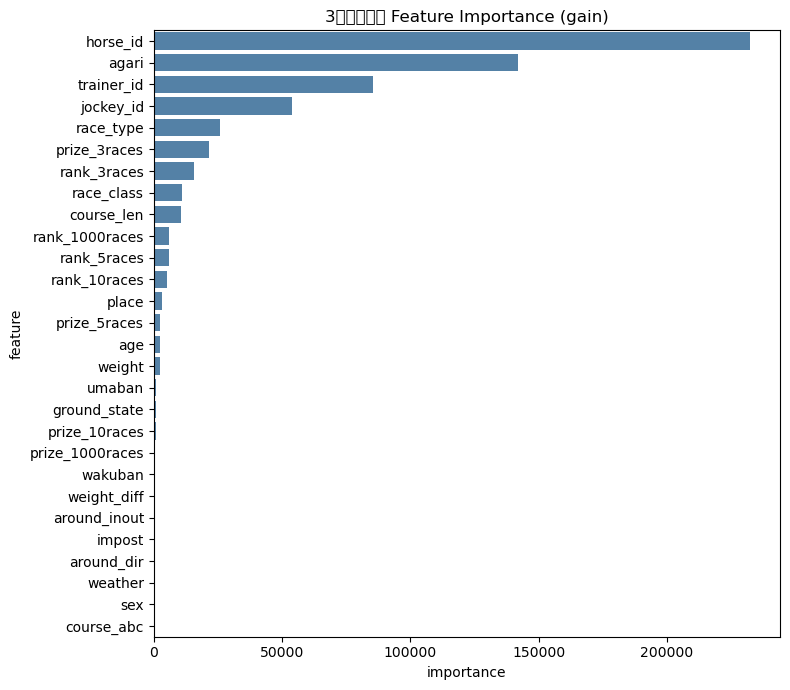

<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

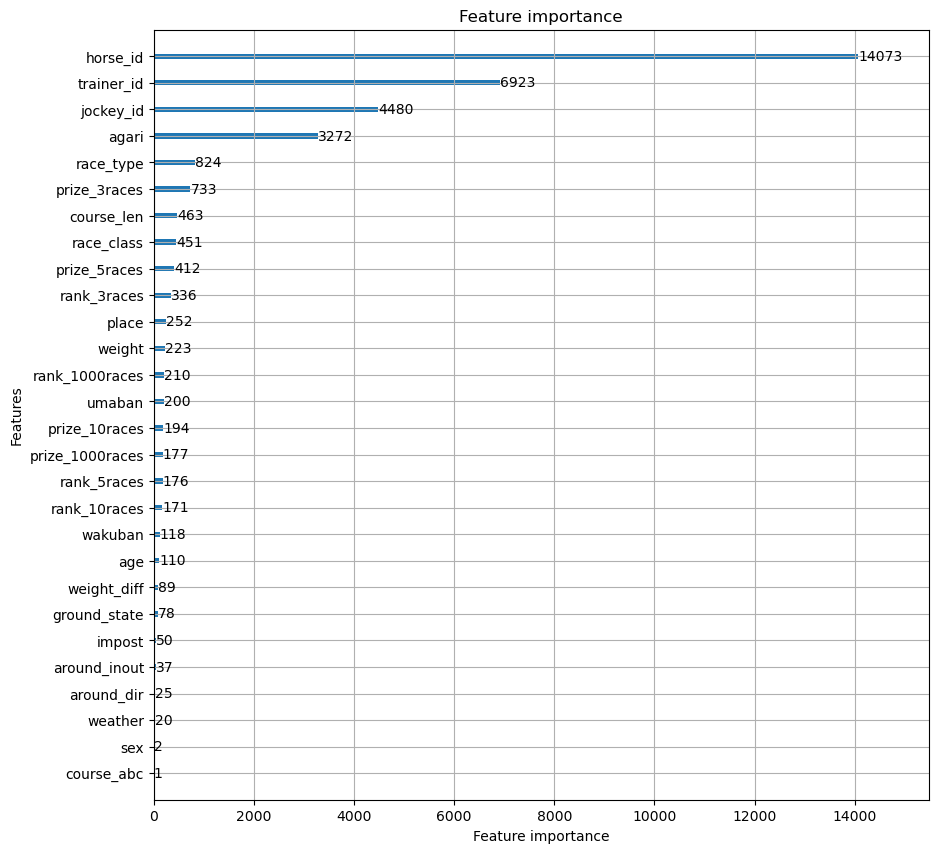

In [149]:
imp_df_tri = get_feature_importance(
    model=model_tri,
    feature_cols=feature_cols_tri,
    importance_type="gain",
    topk=40,
)

display(imp_df_tri)
plot_feature_importance(
    imp_df_tri,
    title="3連系モデル Feature Importance (gain)"
)

lgb.plot_importance(r_tri.model,figsize=(10,10))

In [160]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

df = evaluation_df_tri.copy()

# Top1: 予測1位が実際に1着か
top1_acc = (
    df.loc[df.groupby("race_id")["score"].idxmax()]
      .assign(hit=lambda x: x["rank"]==1)["hit"]
      .mean()
)
print("Top1 acc:", top1_acc)


Top1 acc: 0.3949290932531156


In [161]:
def topk_contains_winner(race_df, k=3):
    topk = race_df.nlargest(k, "score")
    return (topk["rank"]==1).any()

top3_winner_rate = df.groupby("race_id").apply(topk_contains_winner, k=3).mean()
print("Top3 contains winner:", top3_winner_rate)


Top3 contains winner: 0.7266867211001289


In [162]:
def race_spearman(race_df):
    # rankは小さいほど良いので scoreは降順が良い
    return spearmanr(race_df["score"], -race_df["rank"]).correlation

sp = df.groupby("race_id").apply(race_spearman).dropna()
print(sp.describe())


count    2327.000000
mean        0.717812
std         0.201479
min        -0.385294
25%         0.610714
50%         0.769697
75%         0.867133
max         1.000000
dtype: float64


In [167]:
from train_trifecta import plackett_luce_trifecta_topk, trifecta_hit_in_topk

def eval_trifecta_topk_hit_rate(df, cand_n=8, topk=20, temperature=1.0):
    hits = []
    for race_id, race_df in df.groupby("race_id"):
        tri = plackett_luce_trifecta_topk(
            race_df,
            score_col="score",
            horse_col="horse_id",
            umaban_col="umaban",
            cand_n=cand_n,
            topk=topk,
            temperature=temperature,
        )
        if len(tri) == 0:
            continue
        hit = trifecta_hit_in_topk(race_df, tri)
        hits.append(hit)
    return float(np.mean(hits)) if hits else 0.0

print("hit@20:", eval_trifecta_topk_hit_rate(df, cand_n=8, topk=20, temperature=1.0))


hit@20: 0.24022346368715083


In [168]:
temps = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
rows = []
for T in temps:
    h = eval_trifecta_topk_hit_rate(df, cand_n=8, topk=20, temperature=T)
    rows.append((T, h))

out = pd.DataFrame(rows, columns=["T", "hit@20"])
print(out.sort_values("hit@20", ascending=False))


      T    hit@20
4  1.50  0.242372
2  0.75  0.241513
1  0.50  0.240223
3  1.00  0.240223
0  0.25  0.238505
5  2.00  0.238505
6  3.00  0.237215
7  5.00  0.235926


## 前日の予想の結果を表示

In [558]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
autoreload

In [310]:
# 順位保存
from update_results_flat import update_results_flat_for_date
update_results_flat_for_date("2026-01-18")

[update_results_flat_for_date]
 population_csv: /home/jawa/horse_ai/horse_race_prediction/common/data/prediction_population/population_0118.csv
 html_race_dir : /home/jawa/horse_ai/horse_race_prediction/common/data/html/race
 results_flat  : /home/jawa/horse_ai/horse_race_prediction/v2_0_0/data/results_cache/results_flat.csv


(           date       race_id  umaban  rank
 0    2026-01-18  202606010701      10     1
 1    2026-01-18  202606010701       6     2
 2    2026-01-18  202606010701      12     3
 3    2026-01-18  202606010701       7     4
 4    2026-01-18  202606010701      16     5
 ..          ...           ...     ...   ...
 343  2026-01-18  202608010712       2     4
 344  2026-01-18  202608010712       9     5
 345  2026-01-18  202608010712       8     6
 346  2026-01-18  202608010712      10     7
 347  2026-01-18  202608010712       4     8
 
 [348 rows x 4 columns],
 PosixPath('/home/jawa/horse_ai/horse_race_prediction/v2_0_0/data/results_cache/results_flat.csv'))

In [311]:
#払戻金保存
from update_payouts_flat import update_payouts_flat_for_date
update_payouts_flat_for_date("2026-01-18")


[update_payouts_flat_for_date]
 population_csv: /home/jawa/horse_ai/horse_race_prediction/common/data/prediction_population/population_0118.csv
 html_race_dir : /home/jawa/horse_ai/horse_race_prediction/common/data/html/race
 payouts_flat  : /home/jawa/horse_ai/horse_race_prediction/v2_0_0/data/results_cache/payouts_flat.csv


(           date       race_id    bet_type   combo  pay100
 0    2026-01-18  202606010701      tansho      10    1310
 1    2026-01-18  202606010701     fukusho      10     250
 2    2026-01-18  202606010701     fukusho       6     150
 3    2026-01-18  202606010701     fukusho      12     150
 4    2026-01-18  202606010701      umaren    6-10    2410
 ..          ...           ...         ...     ...     ...
 264  2026-01-18  202608010712        wide    3-11     390
 265  2026-01-18  202608010712        wide    1-11     130
 266  2026-01-18  202608010712      umatan     3-1    1760
 267  2026-01-18  202608010712  sanrenpuku  1-3-11     480
 268  2026-01-18  202608010712   sanrentan  3-1-11    5460
 
 [269 rows x 5 columns],
 PosixPath('/home/jawa/horse_ai/horse_race_prediction/v2_0_0/data/results_cache/payouts_flat.csv'))

In [193]:
#最終結果表示
from finalize_day import finalize_day
finalize_day("2026-01-18")